In [1]:
from netgen.meshing import Mesh
from ngsolve import *
from netgen.occ import *
from ngsolve.webgui import Draw

import matplotlib.pylab as plt
import scipy.sparse as sp

In [2]:
def Capacitor3DGeometry(box_size, W, L, d, D, h_max):
    air_box = Box((-box_size, -box_size, -box_size), (box_size, box_size, box_size))
    air_box.faces.name = "Outer"  

    dielectric = Box((-W/2, -d/2, -L/2), (W/2, d/2, L/2))
    dielectric.faces.maxh = h_max/2
    dielectric.name = "dielectric"

    electrode_positive = Box((-W/2, d/2, -L/2), (W/2, (d+D)/2, L/2))
    electrode_positive.faces.maxh = h_max/4
    electrode_positive.faces.name = "electrode_positive"

    electrode_negative = Box((-W/2, -(d+D)/2, -L/2), (W/2, -d/2, L/2))
    electrode_negative.faces.maxh = h_max/4
    electrode_negative.faces.name = "electrode_negative"

    air = air_box - dielectric
    air.name = "air"

    shape = Glue([air, dielectric])
    shape = shape - electrode_positive - electrode_negative

    return shape


def Capacitor3DMesh(shape, h_max):
    
    mesh = Mesh(OCCGeometry(shape, dim=3).GenerateMesh(maxh=h_max))

    return mesh


def Capacitor3DSolver(mesh, FE_order, epsr):

    fes_potential = H1(mesh, order=FE_order, dirichlet="el.*")
    fes_field = HCurl(mesh, order=FE_order-1)

    u = fes_potential.TrialFunction()
    v = fes_potential.TestFunction()

    potential_gf = GridFunction(fes_potential)
    potential_gf.Interpolate(mesh.BoundaryCF({"electrode_positive":1, "electrode_negative":-1 }), mesh.Boundaries(".*"))

    a = BilinearForm(epsr*grad(u)*grad(v)*dx).Assemble()
    
    inv = a.mat.Inverse(freedofs=fes_potential.FreeDofs())
    potential_gf.vec.data -= inv@a.mat * potential_gf.vec

    field_gf = GridFunction(fes_field)
    field_gf.Set(-grad(potential_gf))

    return potential_gf, field_gf, a


In [3]:
clipping = {"function": True, "pnt": (0, 0, 0), "vec": (0, 0, -1)}

In [4]:
box_size, W, L, d, D = 15, 5, 5, 1.5, 0.5
epsr_air, epsr_dielectric = 1.0, 4.0

FE_order = 2
h_max = 1.5

geo = Capacitor3DGeometry(box_size, W, L, d, D, h_max)
mesh = Capacitor3DMesh(geo, h_max)

epsr = mesh.MaterialCF({"air": epsr_air, "dielectric": epsr_dielectric})

In [5]:
Draw(geo,clipping=clipping, settings={"Objects": {"Surface": True}});

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': …

In [6]:
Draw(mesh, clipping=clipping, settings={"Objects": {"Surface": True}});

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Surface': True}…

In [7]:
Draw(epsr, mesh, draw_surf=False, draw_vol=True, clipping=clipping);

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [8]:
phi_gf, E_gf, a = Capacitor3DSolver(mesh, FE_order, epsr)

Number of elements: 5223964729
Nonzero elements: 1950595
Density: 0.00037339360068255927


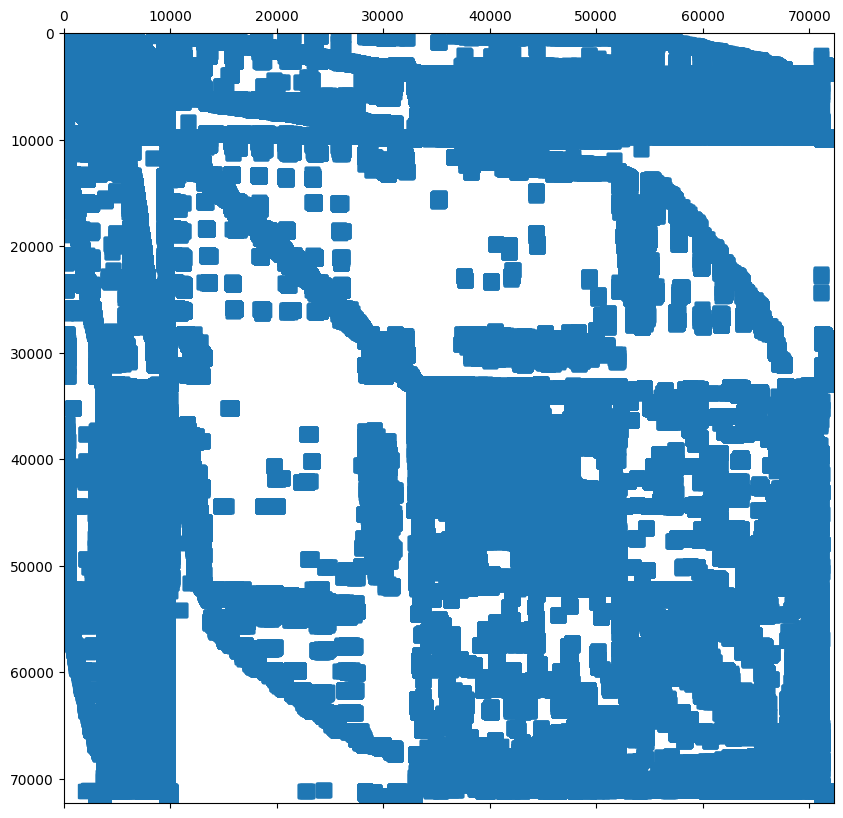

In [9]:
n = a.mat.height
print("Number of elements:", n*n)
print("Nonzero elements:", a.mat.nze)
print("Density:", a.mat.nze / (n*n))

plt.rcParams['figure.figsize'] = (10, 10)
A = sp.csr_matrix(a.mat.CSR())

plt.spy(A)
plt.show()

In [10]:
Draw (phi_gf, scale=5, clipping=clipping);

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [11]:
Draw (E_gf, mesh, min = 0, max = 2, vectors= {"grid_size": 100}, clipping=clipping);

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [12]:
Draw (Norm(E_gf), mesh, min = 0, max = 2, vectors= {"grid_size": 100}, clipping=clipping);

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [28]:
N = 20
margin = 5
y_start = d/2 - 1e-3
x_min, x_max = -W/2 - margin, W/2 + margin
z_min, z_max = 0.0, L/2 + margin


p = [(
     x_min + (x_max - x_min)*i/N,
     y_start,
     z_min + (z_max - z_min)*j/N
    )
    for i in range(N)
    for j in range(N)
]

fieldlines = E_gf._BuildFieldLines(mesh, p, num_fieldlines=400, length=6)

Draw(E_gf, mesh, "Electric field E", 
     draw_vol=True, 
     draw_surf=True, 
     objects=[fieldlines],
     autoscale=True, 
     min = 0, 
     max = 1, 
     settings={"Objects": {"Surface": False}}
     );

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Surface': False…